# Auto-Encoding Variational Bayes (VAE)

**Paper:** Kingma, D. P. & Welling, M. (2013). *Auto-Encoding Variational Bayes.* arXiv:1312.6114

This notebook implements a Variational Auto-Encoder from scratch in PyTorch, following the original paper. The VAE learns a probabilistic latent representation of MNIST digits using the **reparameterization trick** and optimizes the **Evidence Lower Bound (ELBO)**, which combines a reconstruction loss with a KL-divergence regularizer.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Data Loading — MNIST

We load MNIST, flatten each 28×28 image to a 784-dimensional vector, and normalize pixel values to [0, 1]. This matches the paper's setup where images are modeled with a Bernoulli likelihood.

In [2]:
# Hyperparameters
BATCH_SIZE = 128
LATENT_DIM = 2       # 2D for visualization (paper also experimented with 5, 10, 20)
HIDDEN_DIM = 512     # Hidden units in encoder/decoder (paper used 500 for MNIST)
EPOCHS = 50
LR = 1e-3

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Image dim: {784}')
print(f'Batch shape: {next(iter(train_loader))[0].shape}')

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 65.5k/9.91M [00:00<00:25, 386kB/s]

  2%|▏         | 164k/9.91M [00:00<00:19, 492kB/s] 

  6%|▌         | 557k/9.91M [00:00<00:07, 1.30MB/s]

 21%|██        | 2.06M/9.91M [00:00<00:01, 4.22MB/s]

...

 81%|████████▏ | 1.34M/1.65M [00:00<00:00, 3.23MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 8.64MB/s]

Train samples: 60000
Test samples: 10000
Image dim: 784
Batch shape: torch.Size([128, 784])


## 3. Encoder Network (Probabilistic Encoder)

The encoder maps input x to the parameters of the approximate posterior q(z|x) = N(mu(x), diag(sigma^2(x))). We output log-variance instead of variance for numerical stability.

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=2):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

## 4. Reparameterization Trick

The key innovation of the paper. Instead of sampling z directly from q(z|x) (which has no gradient), we express z as:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

This makes the sampling differentiable with respect to mu and sigma, allowing standard backpropagation through the stochastic layer.

In [4]:
def reparameterize(mu, logvar):
    """
    Reparameterization trick: z = mu + std * eps
    where eps ~ N(0, I) and std = exp(0.5 * logvar)
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z

## 5. Decoder Network (Probabilistic Decoder)

The decoder maps a latent code z to the parameters of the likelihood p(x|z). For MNIST (binary-like pixels in [0,1]), we use a Bernoulli likelihood, so the decoder outputs probabilities via a sigmoid.

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=512, output_dim=784):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        x_recon = torch.sigmoid(self.fc2(h))
        return x_recon

## 6. VAE Model

Combines the encoder, reparameterization, and decoder into a single module.

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

# Initialize model
model = VAE(input_dim=784, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM).to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=2, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=512, bias=True)
    (fc2): Linear(in_features=512, out_features=784, bias=True)
  )
)
Total parameters: 807,700


## 7. Loss Function — Negative ELBO

The ELBO (Evidence Lower Bound) has two terms:

1. **Reconstruction loss** (negative log-likelihood): Binary Cross-Entropy between x and x_recon
2. **KL-divergence** (regularizer): Closed-form for Gaussian prior and posterior

$$\mathcal{L}(\theta, \phi; x) = -D_{KL}(q_\phi(z|x) || p(z)) + \mathbb{E}_{q(z|x)}[\log p_\theta(x|z)]$$

$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{J} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

We minimize the negative ELBO.

In [7]:
def vae_loss(x_recon, x, mu, logvar):
    """
    Computes the negative ELBO (loss to minimize):
    - Reconstruction loss: BCE (Bernoulli likelihood)
    - KL divergence: closed-form for Gaussian distributions
    """
    # Reconstruction loss (sum over pixels, mean over batch)
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # KL divergence: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss (per-sample average)
    loss = (recon_loss + kl_div) / x.size(0)
    return loss, recon_loss / x.size(0), kl_div / x.size(0)

## 8. Training Loop

We train the VAE using Adam optimizer for 50 epochs. We track the total loss, reconstruction loss, and KL divergence separately to monitor the balance between reconstruction quality and latent space regularization.

In [8]:
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
recon_losses = []
kl_losses = []

for epoch in range(EPOCHS):
    total_loss = 0
    total_recon = 0
    total_kl = 0
    num_batches = 0

    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        x_recon, mu, logvar = model(data)
        loss, recon, kl = vae_loss(x_recon, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    avg_recon = total_recon / num_batches
    avg_kl = total_kl / num_batches

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}]  Loss: {avg_loss:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}')

print('\nTraining complete!')

Epoch [1/50]  Loss: 186.8032  Recon: 181.2899  KL: 5.5133


Epoch [10/50]  Loss: 153.6452  Recon: 147.7212  KL: 5.9240


Epoch [20/50]  Loss: 149.2796  Recon: 143.0903  KL: 6.1893


Epoch [30/50]  Loss: 146.9022  Recon: 140.5718  KL: 6.3304


Epoch [40/50]  Loss: 145.4369  Recon: 139.0145  KL: 6.4224


Epoch [50/50]  Loss: 144.3804  Recon: 137.8990  KL: 6.4814

Training complete!


## 9. Training Loss Curves

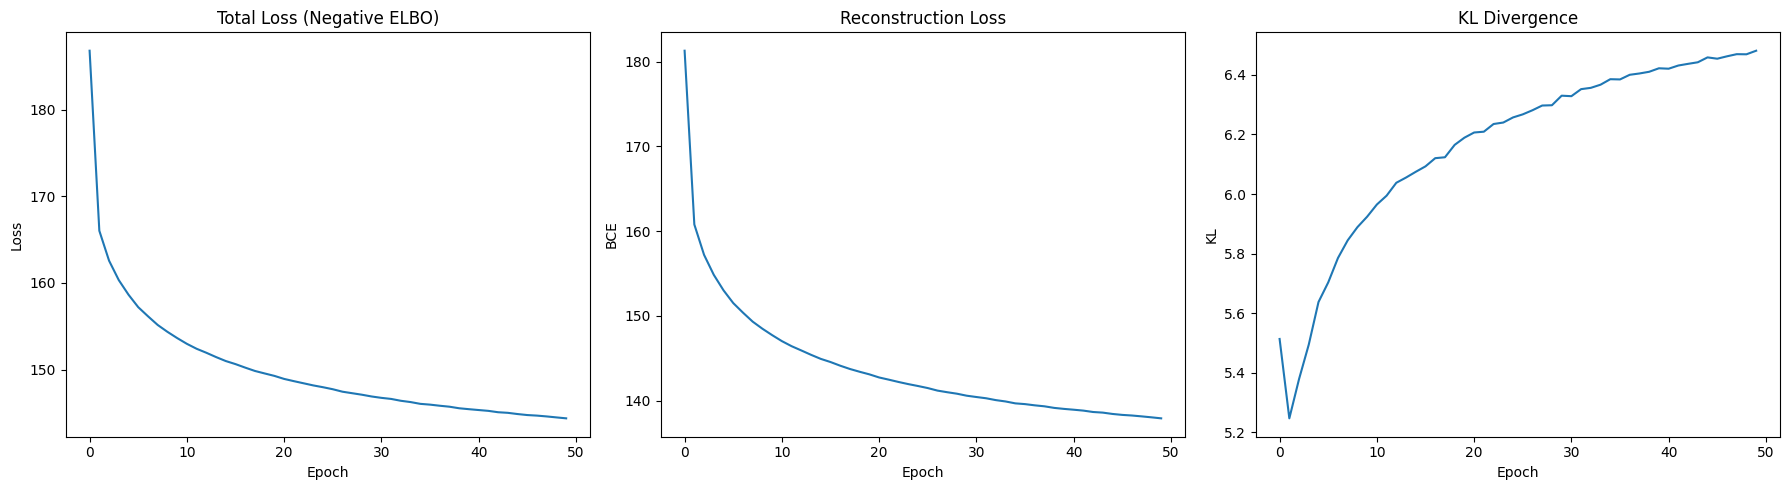

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses)
axes[0].set_title('Total Loss (Negative ELBO)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(recon_losses)
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE')

axes[2].plot(kl_losses)
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL')

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Visualization — Original vs. Reconstructed

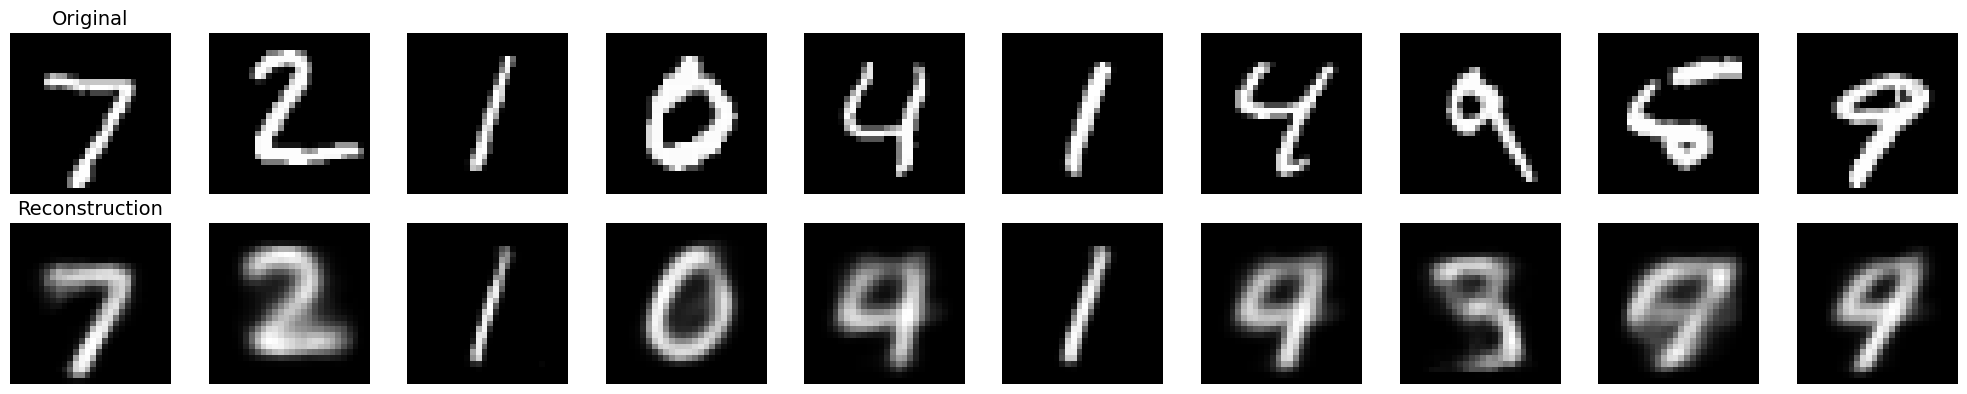

In [10]:
model.eval()
with torch.no_grad():
    data, labels = next(iter(test_loader))
    data = data.to(device)
    x_recon, _, _ = model(data)

    # Show first 10 images
    n = 10
    fig, axes = plt.subplots(2, n, figsize=(20, 4))
    for i in range(n):
        # Original
        axes[0, i].imshow(data[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=14)

        # Reconstruction
        axes[1, i].imshow(x_recon[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstruction', fontsize=14)

    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Visualization — 2D Latent Space Scatter

Since we used a 2D latent space, we can plot each test image's encoded (mu_1, mu_2) coordinates, colored by digit class. This shows how the VAE organizes different digit classes in the latent space.

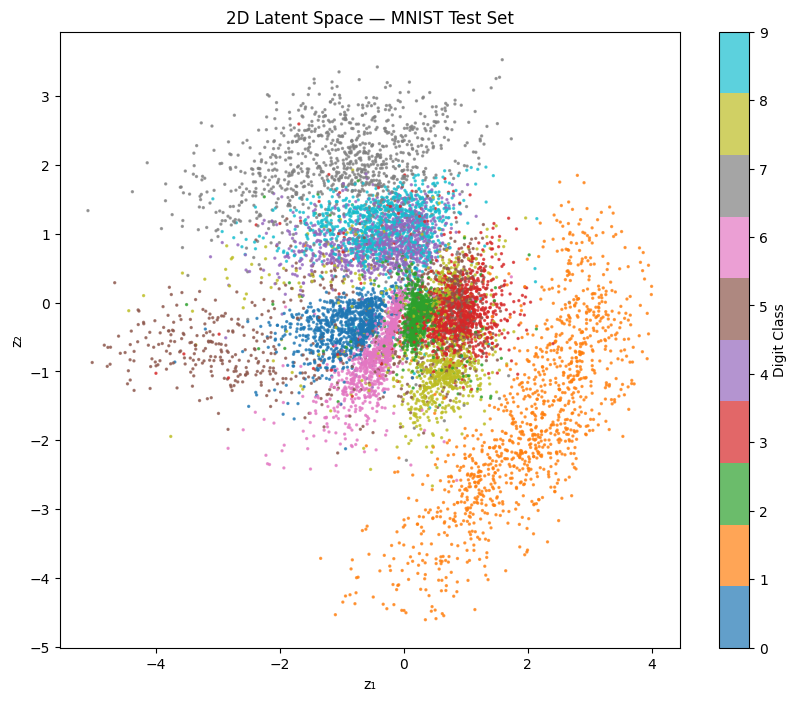

In [11]:
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.encoder(data)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title('2D Latent Space — MNIST Test Set')
plt.xlabel('z₁')
plt.ylabel('z₂')
plt.savefig('latent_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Visualization — Latent Space Interpolation

We sample a grid of points in the 2D latent space and decode each to an image, showing the learned manifold. This reveals how the VAE learned to smoothly interpolate between different digit shapes.

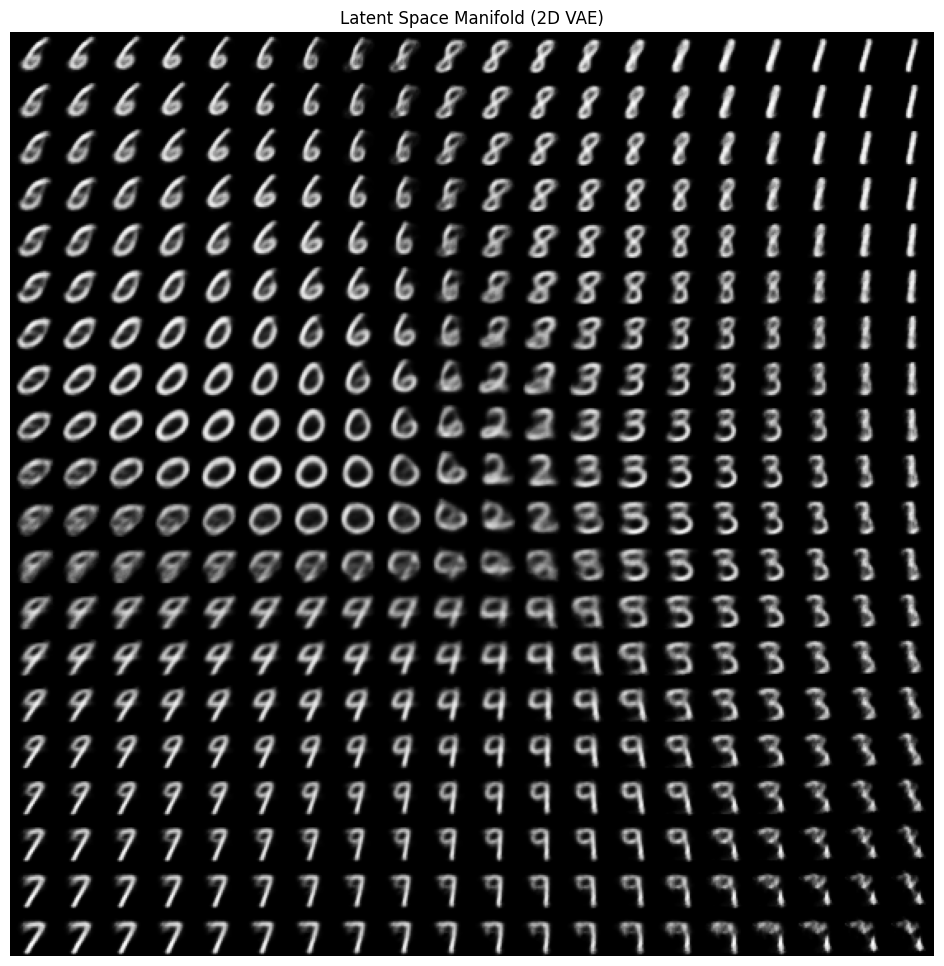

In [12]:
model.eval()
with torch.no_grad():
    # Sample a grid in latent space
    n = 20
    z_grid_x = np.linspace(-2, 2, n)
    z_grid_y = np.linspace(-2, 2, n)

    figure = np.zeros((28 * n, 28 * n))

    for i, yi in enumerate(z_grid_y):
        for j, xi in enumerate(z_grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            img = model.decoder(z).cpu().numpy().reshape(28, 28)
            figure[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img

    plt.figure(figsize=(12, 12))
    plt.imshow(figure, cmap='gray')
    plt.title('Latent Space Manifold (2D VAE)')
    plt.axis('off')
    plt.savefig('latent_manifold.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Visualization — Linear Interpolation Between Digits

We encode two real test images and linearly interpolate between their latent codes, decoding each intermediate point. This shows smooth morphing from one digit to another through the latent space.

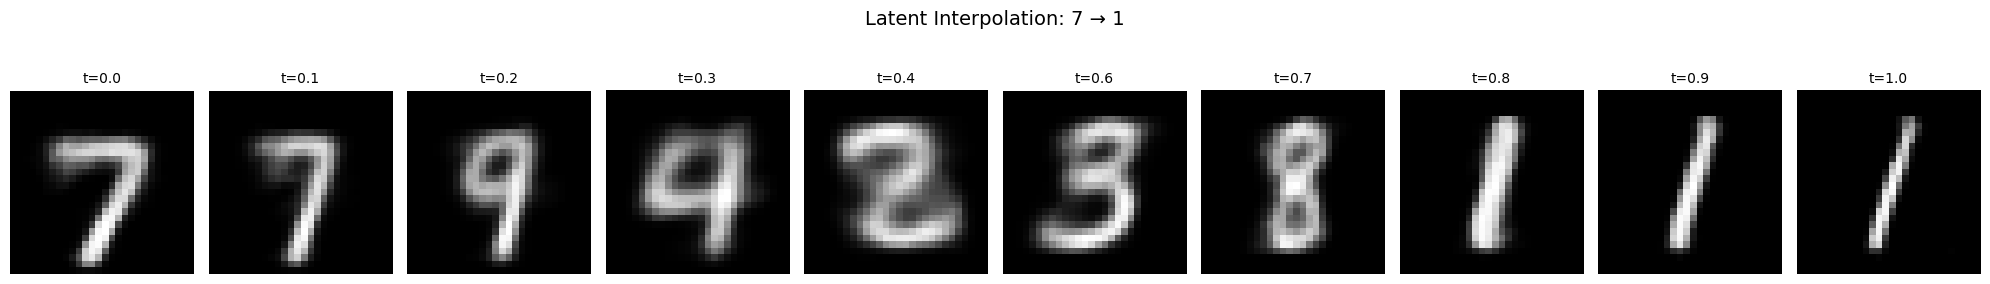

In [13]:
model.eval()
with torch.no_grad():
    # Get two test images of different digits
    data, labels = next(iter(test_loader))
    data = data.to(device)

    # Find one '7' and one '1'
    idx_7 = (labels == 7).nonzero(as_tuple=True)[0][0].item()
    idx_1 = (labels == 1).nonzero(as_tuple=True)[0][0].item()

    img1 = data[idx_7:idx_7+1]
    img2 = data[idx_1:idx_1+1]

    # Encode both
    mu1, _ = model.encoder(img1)
    mu2, _ = model.encoder(img2)

    # Interpolate
    n_steps = 10
    fig, axes = plt.subplots(1, n_steps, figsize=(20, 3))
    for i, t in enumerate(np.linspace(0, 1, n_steps)):
        z = mu1 * (1 - t) + mu2 * t
        img = model.decoder(z).cpu().numpy().reshape(28, 28)
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f't={t:.1f}', fontsize=10)

    plt.suptitle('Latent Interpolation: 7 → 1', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('interpolation.png', dpi=150, bbox_inches='tight')
    plt.show()

## 14. Random Sampling from the Prior

We sample z ~ N(0, I) directly from the prior (not from any encoded image) and decode to generate entirely new digit images. This demonstrates the generative capability of the VAE.

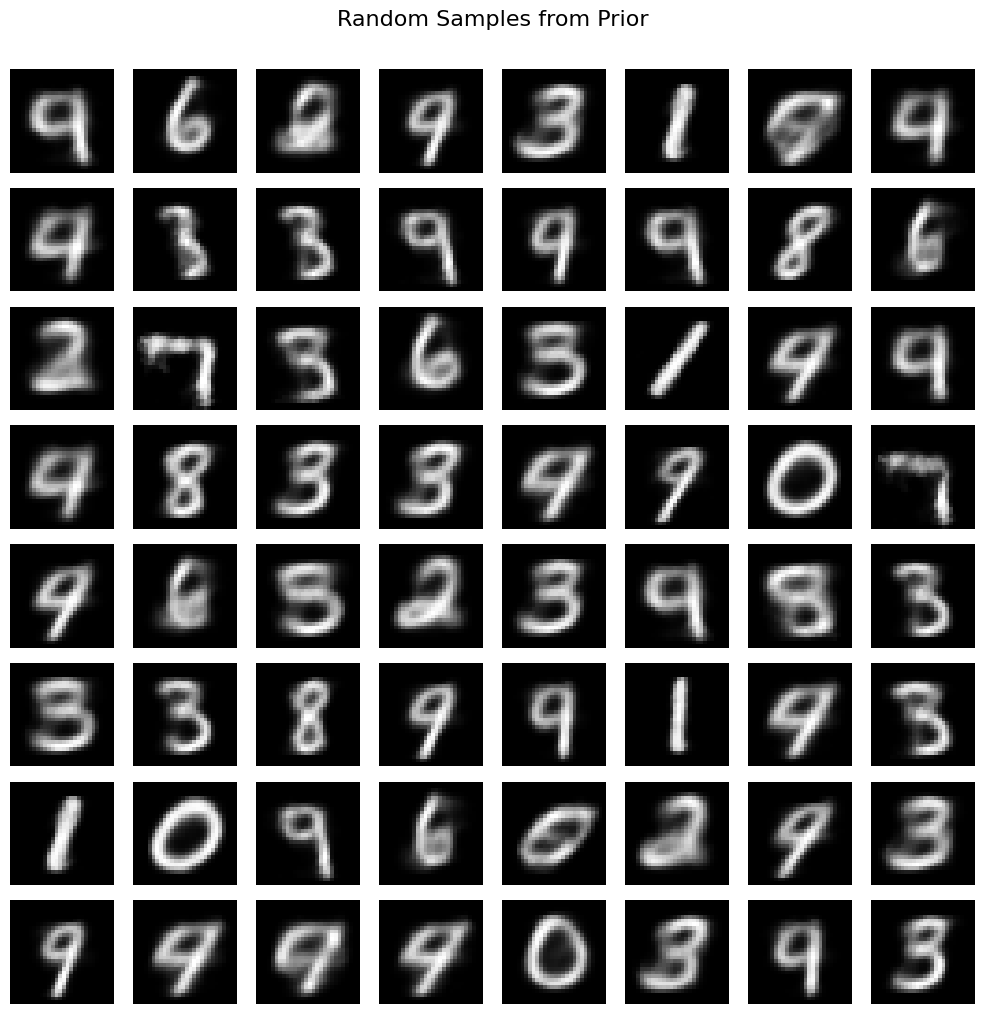

In [14]:
model.eval()
with torch.no_grad():
    # Sample from prior
    z_samples = torch.randn(64, LATENT_DIM).to(device)
    generated = model.decoder(z_samples).cpu().numpy()

    # Display 8x8 grid
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            axes[i, j].imshow(generated[idx].reshape(28, 28), cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle('Random Samples from Prior', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

## 15. Higher-Dimensional Latent Space (20D)

With only a 2D latent space, the VAE sacrifices reconstruction quality for visualization. Here we train a VAE with 20D latent space (matching the paper's experiments) to demonstrate improved reconstruction quality.

In [15]:
# Train a 20D VAE
LATENT_DIM_20 = 20
model_20d = VAE(input_dim=784, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM_20).to(device)
optimizer_20d = optim.Adam(model_20d.parameters(), lr=LR)

print(f'Training 20D VAE for {EPOCHS} epochs...')
for epoch in range(EPOCHS):
    total_loss = 0
    num_batches = 0

    model_20d.train()
    for data, _ in train_loader:
        data = data.to(device)
        optimizer_20d.zero_grad()

        x_recon, mu, logvar = model_20d(data)
        loss, _, _ = vae_loss(x_recon, data, mu, logvar)

        loss.backward()
        optimizer_20d.step()

        total_loss += loss.item()
        num_batches += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}]  Loss: {total_loss/num_batches:.4f}')

print('\n20D VAE training complete!')

Training 20D VAE for 50 epochs...


Epoch [1/50]  Loss: 159.5750


Epoch [10/50]  Loss: 105.4264


Epoch [20/50]  Loss: 103.2844


Epoch [30/50]  Loss: 102.1627


Epoch [40/50]  Loss: 101.4783


Epoch [50/50]  Loss: 100.9482

20D VAE training complete!


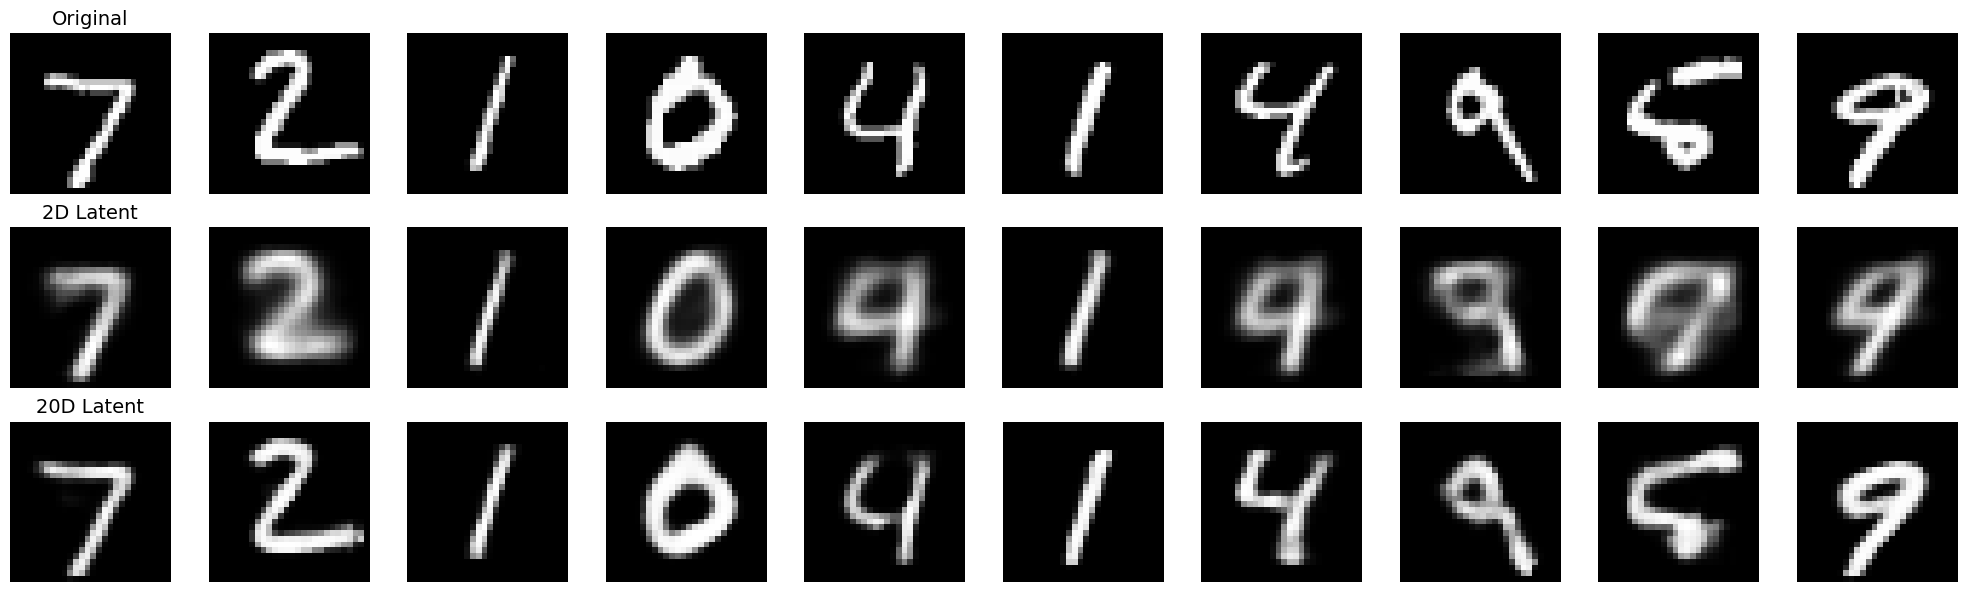

In [16]:
# Compare reconstructions: 2D vs 20D
model.eval()
model_20d.eval()

with torch.no_grad():
    data, labels = next(iter(test_loader))
    data = data.to(device)

    x_recon_2d, _, _ = model(data)
    x_recon_20d, _, _ = model_20d(data)

    n = 10
    fig, axes = plt.subplots(3, n, figsize=(20, 6))
    for i in range(n):
        axes[0, i].imshow(data[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=14)

        axes[1, i].imshow(x_recon_2d[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('2D Latent', fontsize=14)

        axes[2, i].imshow(x_recon_20d[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title('20D Latent', fontsize=14)

    plt.tight_layout()
    plt.savefig('comparison_2d_20d.png', dpi=150, bbox_inches='tight')
    plt.show()

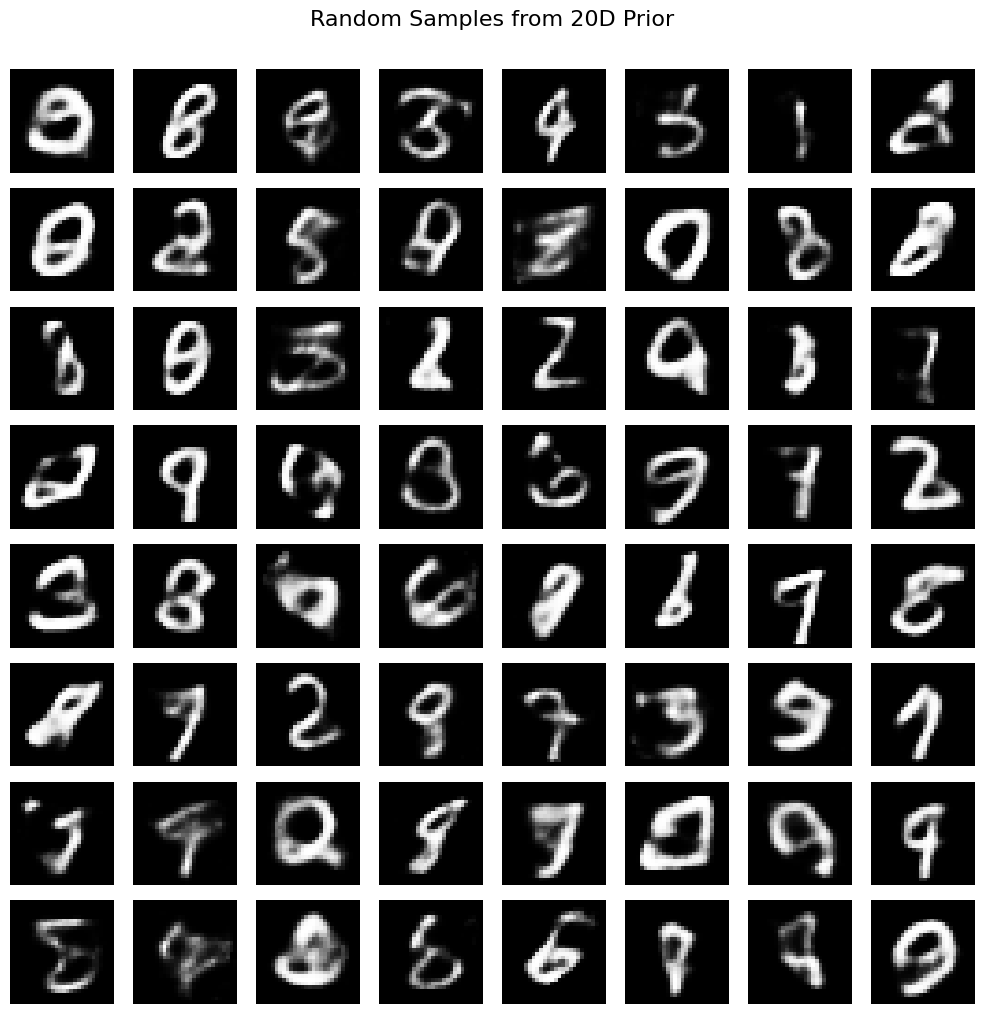


Done! VAE implementation complete.


In [17]:
# Generate samples from 20D prior
with torch.no_grad():
    z_samples = torch.randn(64, LATENT_DIM_20).to(device)
    generated = model_20d.decoder(z_samples).cpu().numpy()

    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            axes[i, j].imshow(generated[idx].reshape(28, 28), cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle('Random Samples from 20D Prior', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('random_samples_20d.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\nDone! VAE implementation complete.')

## Summary

This notebook implemented the Variational Auto-Encoder from Kingma & Welling (2013):

1. **Encoder** — MLP that maps images to (mu, logvar) of a diagonal Gaussian posterior
2. **Reparameterization trick** — z = mu + sigma * epsilon, enabling backprop through sampling
3. **Decoder** — MLP that maps latent codes back to image probabilities
4. **ELBO loss** — Reconstruction (BCE) + KL-divergence (closed-form for Gaussians)
5. **Visualization** — 2D latent scatter, manifold interpolation, digit morphing, prior sampling

Key takeaways:
- The **reparameterization trick** is the core innovation — it makes stochastic sampling differentiable
- The **KL-divergence term** is not just a regularizer but a principled component of the variational bound
- The **2D latent space** produces beautiful visualizations but sacrifices reconstruction quality
- The **20D latent space** produces much sharper reconstructions and samples
- VAEs learn a **structured, continuous latent space** where interpolation produces meaningful transitions

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
